## Lock in the real-world graph: Volkerak
In this notebook, we set up a basic simulation where two vessels cross a lock complex in a real-world graph. We take the eastern lock chamber of the Volkerak sluices (rightern most lock chamber in the picture below).

![OpenTNSim-Volkeraksluizen](figures/0211_Volkeraksluizen.png)


In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from shapely.geometry import Polygon

# package to navigate through files and folders
from pathlib import Path

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.utils import create_object

# import of utils for graph construction andvisualization
from opentnsim.graph.mixins import FIS
from opentnsim.graph.utils import find_edges_in_a_polygon, find_nodes_in_a_polygon, get_trajectory, create_transformer
from opentnsim.graph.calculations import transform_geometry, merge_two_consecutive_edges_based_on_shared_node

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
from opentnsim.lock.visualizations import spatially_visualize_lock_complex

# package(s) needed for inspecting the output
import pandas as pd
import geopandas as gpd

# package needed to download the lock geometry
import requests

# package to assess the progress of functions
from tqdm import tqdm

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.3.2a2.dev3+g514a752b4.d20260603


#### 0. Create environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessels sail from one side of the lock to another side.

In [3]:
# load the processed version from the Fairway Information System graph provided by Rijkswaterstaat
FG = FIS.load_network(version="0.3")

The edges in the FIS-graph (FG) have geometry attributes in the WGS84-reference system. Distances between points in this reference system are calculated in degrees, but edges in the FG have a length_m attribute with their length in meters. Later, we will do some operations in which we need to accurately convert units from WGS84 (degrees) into meters. For this, we use the Amersfoort / RD New reference system, which locally in the Netherlands gives the most accurate results. As the original length_m deviates from the distances measured in the RD-system, we have to update the length_m paramters

In [4]:
transformer = create_transformer(crs_out='EPSG:28992') #From WGS84 to Amersfoort / RD New reference system
for edge in tqdm(FG.edges):
    geometry = get_trajectory(FG,edge[0],edge[1])[0]
    if geometry is not None:
        geometry_m = transform_geometry(geometry, transformer=transformer) 
        FG.edges[edge]['geometry'] = geometry
        FG.edges[edge]['length_m'] = geometry_m.length

100%|██████████████████████████████████████████████████████████████████████████| 16164/16164 [00:04<00:00, 3466.70it/s]


We add the graph to the environment

In [5]:
# add graph to environment
env.graph = FG

#### 1+ Infrastructure
We have to schematize our sluice of the Volkerak. For this, we have to download the geometry of the sluice. For this, we use [openstreetmap](https://www.openstreetmap.org/#map=17/51.689765/4.410560) and create an API.

In [6]:
use_openstreetmap = False

if use_openstreetmap:
    # Use faster server
    url = "https://overpass.kumi.systems/api/interpreter"
    
    # Berlin bounding box (faster than area lookup)
    query = """
    [out:json][timeout:180];
    nwr["lock_name"~"Oostkolk"](51.68005,4.38958,51.70062,4.42933);
    out geom;
    """
    
    response = requests.get(url, params={'data': query})
    data = response.json()
    
    # Convert to DataFrame
    elements = data["elements"]
    
    df = pd.json_normalize(elements)
    
    # Create geometry column
    df['geometry'] = df.apply(lambda row: Polygon((p["lon"], p["lat"]) for p in row.geometry), axis=1)
    
    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

else:
    gdf = gpd.read_file(Path.cwd() / Path('data/Locking') / 'Volkerak_lock.geojson')

# We get two objects that are similar
gdf.head()

,type,id,bounds.minlat,bounds.minlon,bounds.maxlat,bounds.maxlon,tags.CEMT,tags.boat,tags.image,tags.length,...,tags.name,tags.natural,tags.phone,tags.url,tags.vhf,tags.water,tags.wikidata,tags.wikipedia,tags.waterway,geometry
0,way,56198966,51.688860,4.407993,51.691111,4.412082,VIb,yes,https://photos.app.goo.gl/N17kH1rdrwD75BD69,331.5,...,Volkeraksluizen,water,+31 88 797 4990,https://youtu.be/VHbaJfyRVzU,7;25;64,lock,Q1886412,nl:Volkeraksluizen,NaN,"POLYGON ((4.40799 51.68904, 4.40801 51.68903, ..."
1,way,251906187,51.688925,4.408070,51.691053,4.411981,VIb,yes,NaN,331.5,...,Volkeraksluizen,NaN,+31 88 797 4990,NaN,7;25;64,NaN,Q1886412,nl:Volkeraksluizen,canal,"POLYGON ((4.40807 51.68892, 4.40823 51.68901, ..."


We store the geometry of the first instance to be used as the geometry for our lock

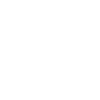

In [7]:
lock_geometry = gdf.geometry.iloc[0]
lock_geometry

We also have to set the depth of the lock

In [8]:
lock_depth = 6.2 #information based on RWS

##### Lock chamber
With the above information, we try to add a Lock Chamber to the environment:

In [9]:
try:
    lock_chamber = IsLockChamber(env=env,
                                 name='Oostkolk',
                                 geometry = lock_geometry,
                                 lock_depth = lock_depth,
                                 crs_m='EPSG:4087') #Amersfoort / RD New reference system
except:
    print('The FIS-graph is not fit to model the lock chamber, as the lock geometry covers multiple edges. '+
          'The locking-module only supports locks on single edges, without nodes within the geometry. We need to modify the FIS-graph.')

The FIS-graph is not fit to model the lock chamber, as the lock geometry covers multiple edges. The locking-module only supports locks on single edges, without nodes within the geometry. We need to modify the FIS-graph.


#### 1. Create graph (Second try)

There are nodes within the lock geometry, which we have to find, merge their edges and remove.

In [10]:
nodes_within_the_lock_chamber = find_nodes_in_a_polygon(FG, lock_geometry)
nodes_within_the_lock_chamber

['L42863_A', 'L42863_B']

We can remove the nodes and merge the edges between them (using a predefined function)

In [11]:
FG = merge_two_consecutive_edges_based_on_shared_node(FG, nodes_within_the_lock_chamber)

Check if we now have a single lock edge

In [12]:
lock_node_A, lock_node_B = find_edges_in_a_polygon(FG,lock_geometry)[0]
lock_edge = (lock_node_A, lock_node_B)
lock_edge

('8862498', 'B34113_A')

In [13]:
env.graph = FG

#### 1+ Add infrastructure (Second try)

In [14]:
lock_chamber = IsLockChamber(env=env,
                             name='Oostkolk',
                             geometry = lock_geometry,
                             lock_depth = lock_depth,
                             sailing_distance_to_crossing_point_A = 260,
                             sailing_distance_to_crossing_point_B = 370,
                             crs_m='EPSG:28992') #Amersfoort / RD New reference system

In [15]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   lock_chamber = lock_chamber,
                                   distance_from_lock_gate_A = 260)

In [16]:
waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   lock_chamber = lock_chamber,
                                   distance_from_lock_gate_B = 370)

In [17]:
node_A = waiting_area_A.edge[0]
node_B = waiting_area_B.edge[0]

lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = [node_A, node_B],
                             env=env,
                             name = 'Lock complex',)

We can visualize the lock complex

In [18]:
spatially_visualize_lock_complex(lock_complex)

#### 2. Create agents

In [19]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [20]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [21]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes[node_A]['geometry'],     # required by Locatable
    "route": nx.dijkstra_path(env.graph, node_A, node_B),# required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes[node_B]['geometry'],     # required by Locatable
    "route": nx.dijkstra_path(env.graph, node_B, node_A),# required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2));

#### 3. Run simulation

In [22]:
env.run()

#### 4. Inspect output

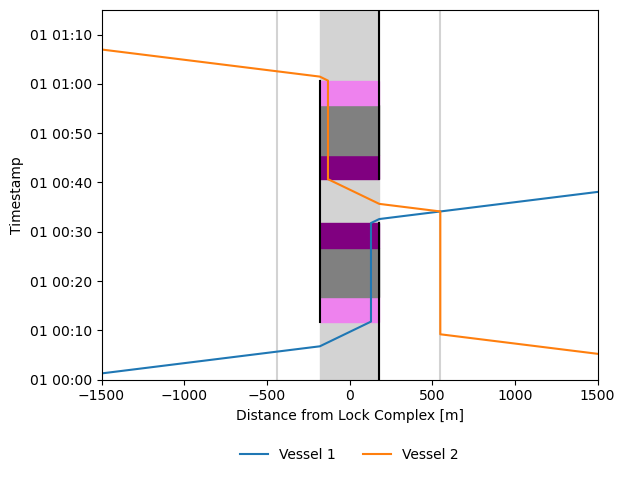

In [23]:
# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -1500, 
                        xlimmax = 1500,
                        ylimmin = datetime.datetime(2025, 1, 1, 0, 0, 0),
                        ylimmax = datetime.datetime(2025, 1, 1, 1, 15, 0),
                        method = 'Matplotlib')

In [24]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8862498 to node B34113_A start,2025-01-01 00:00:00.000000,0.000000,POINT (4.43027504290525 51.7000442261129)
1,Sailing to waiting area start,2025-01-01 00:00:00.000000,0.000000,POINT (4.43027504290525 51.7000442261129)
2,Sailing to waiting area stop,2025-01-01 00:05:39.099572,1356.398292,POINT (4.4148511161708095 51.69255535654485)
3,Sailing to first lock gate start,2025-01-01 00:05:39.099572,1356.398292,POINT (4.4148511161708095 51.69255535654485)
4,Sailing to first lock gate stop,2025-01-01 00:06:44.099572,1616.398292,POINT (4.411997212001862 51.691033759393214)
5,Sailing to position in lock start,2025-01-01 00:06:44.099572,1616.398292,POINT (4.411997212001862 51.691033759393214)
6,Sailing to position in lock stop,2025-01-01 00:11:44.894166,1925.882507,POINT (4.408608545334125 51.689216565791895)
7,Waiting for lock gate closing start,2025-01-01 00:11:44.894167,1925.882507,POINT (4.408608545334125 51.689216565791895)
8,Waiting for lock gate closing stop,2025-01-01 00:16:44.894167,1925.882507,POINT (4.408608545334125 51.689216565791895)
9,Waiting for lock levelling start,2025-01-01 00:16:44.894167,1925.882507,POINT (4.408608545334125 51.689216565791895)


In [25]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8868426 to node B34113_B start,2025-01-01 00:05:00.000000,0.000000,POINT (4.39253941691783 51.6812485487213)
1,Sailing to waiting area start,2025-01-01 00:05:00.000000,0.000000,POINT (4.39253941691783 51.6812485487213)
2,Sailing to waiting area stop,2025-01-01 00:09:10.601541,1002.406167,POINT (4.403936502141388 51.686815240448716)
3,Waiting for lock operation start,2025-01-01 00:09:10.601541,1002.406167,POINT (4.403936502141388 51.686815240448716)
4,Waiting for lock operation stop,2025-01-01 00:34:05.990280,1002.406167,POINT (4.403936502141388 51.686815240448716)
5,Sailing from node 8868426 to node B34113_B stop,2025-01-01 00:35:28.261914,1331.492705,POINT (4.407620736969263 51.688686277276325)
6,Sailing from node B34113_B to node B34113_A start,2025-01-01 00:35:28.261914,1331.492705,POINT (4.407620736969263 51.688686277276325)
7,Sailing from node B34113_B to node B34113_A stop,2025-01-01 00:35:30.274553,1339.543258,POINT (4.4077088440752465 51.688733575668216)
8,Sailing from node B34113_A to node 8862498 start,2025-01-01 00:35:30.274553,1339.543258,POINT (4.4077088440752465 51.688733575668216)
9,Sailing to first lock gate start,2025-01-01 00:35:30.274553,1339.543258,POINT (4.4077088440752465 51.688733575668216)


In [26]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(lock_chamber.logbook)

print("'{}' logbook data:".format(lock_chamber.name))  
print('')

display(df)

'Oostkolk' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock gate closing start,2025-01-01 00:11:44.894167,8862498,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
1,Lock gate closing stop,2025-01-01 00:16:44.894167,8862498,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
2,Lock levelling start,2025-01-01 00:16:44.894167,8862498,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
3,Lock levelling stop,2025-01-01 00:26:44.894167,B34113_A,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
4,Lock gate opening start,2025-01-01 00:26:44.894167,B34113_A,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
5,Lock gate opening stop,2025-01-01 00:31:44.894167,B34113_A,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
6,Lock gate closing start,2025-01-01 00:40:39.284875,B34113_A,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
7,Lock gate closing stop,2025-01-01 00:45:39.284875,B34113_A,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
8,Lock levelling start,2025-01-01 00:45:39.284875,B34113_A,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
9,Lock levelling stop,2025-01-01 00:55:39.284875,8862498,"POLYGON ((4.4079928 51.6890437, 4.4080059 51.6..."
